# Progetto: Rilevazione delle minacce sul dataset CICIDS-2017 (DDos)

Questo notebook utilizza il file **Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv** per effettuare un'analisi esplorativa (EDA) e costruire un modello di rilevazione delle minacce. Il notebook è scritto in italiano, contiene commenti e usa **seaborn** per l'EDA e **scikit-learn** per il modello.

## 1) Import e caricamento dati

Assicurati che il file **Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv** sia nella stessa cartella del notebook.

In [ ]:
# Import librerie principali
import pandas as pd
import numpy as np

# Librerie per EDA: seaborn e matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn per preprocessing e modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Percorso file (modifica se necessario)
csv_file = 'https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# Caricamento (si assume che il file sia in formato CSV standard)
df = pd.read_csv(csv_file)

# Mostra le prime righe
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df[' Label'].value_counts()

,count
Label,
DDoS,128027
BENIGN,97718


## 2) Analisi dati

### Descrizione delle 8 feature selezionate

1. **Flow Duration**: durata totale del flusso (in microsecondi o millisecondi a seconda della fonte). Flussi molto brevi o molto lunghi possono indicare scansioni, connessioni fallite, o DoS.

2. **Total Fwd Packets**: numero totale di pacchetti inviati nella direzione "forward" (originator → responder). Utile per capire il volume di richieste/iniziative nel flusso.

3. **Total Bwd Packets**: numero totale di pacchetti nella direzione "backward" (responder → originator). L'asimmetria tra forward e backward aiuta a rilevare esfiltrazione, heartbeat botnet o risposte minime.

4. **Packet Length Mean**: dimensione media (in bytes) di tutti i pacchetti del flusso. Pacchetti costantemente piccoli o costantemente grandi sono indicatori di tipi specifci di traffico (es. SSH brute-force vs trasferimenti file).

5. **Flow Packets/s**: tasso di pacchetti nel flusso (pacchetti al secondo). Valori molto alti sono tipici di DoS o flooding.

6. **Flow Bytes/s**: throughput del flusso (bytes al secondo). Utile per distinguere tra traffico ad alto volume e traffico a basso volume.

7. **SYN Flag Count**: numero di pacchetti con il flag SYN nel flusso. Scansioni SYN (SYN flood, port scan) e handshake incompleti aumentano questo valore.

8. **Flow IAT Mean**: tempo medio tra arrivi di pacchetti (inter-arrival time medio) nel flusso. Pattern regolari o intervalli molto piccoli/frequenti possono rivelare botnet o DoS.


In [ ]:
important_features = [
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    " Packet Length Mean",
    " Flow Packets/s",
    "Flow Bytes/s",
    " SYN Flag Count",
    " Flow IAT Mean",
    " Label"  # opzionale, per supervised learning
]

df = df[important_features]

In [ ]:
df.columns = df.columns.str.strip()

filter = (df['Flow Packets/s'] == np.inf) | (df['Flow Bytes/s'] == np.inf) | (df['Flow Bytes/s'] == np.nan)
df[filter].shape[0]
df = df[~filter]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225711 entries, 0 to 225744
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Flow Duration           225711 non-null  int64  
 1   Total Fwd Packets       225711 non-null  int64  
 2   Total Backward Packets  225711 non-null  int64  
 3   Packet Length Mean      225711 non-null  float64
 4   Flow Packets/s          225711 non-null  float64
 5   Flow Bytes/s            225711 non-null  float64
 6   SYN Flag Count          225711 non-null  int64  
 7   Flow IAT Mean           225711 non-null  float64
 8   Label                   225711 non-null  object 
dtypes: float64(4), int64(4), object(1)
memory usage: 17.2+ MB


In [ ]:
label_map = {
    'DDoS': 1,
    'BENIGN': 0
}

df['Label'] = df['Label'].map(label_map)
df['Label'].value_counts()

,count
Label,
1,128025
0,97686


In [ ]:
print(df.describe().to_csv())

,Flow Duration,Total Fwd Packets,Total Backward Packets,Packet Length Mean,Flow Packets/s,Flow Bytes/s,SYN Flag Count,Flow IAT Mean,Label
count,225711.0,225711.0,225711.0,225711.0,225711.0,225711.0,225711.0,225711.0,225711.0
mean,16244095.090549419,4.875389325287647,4.573423537178073,515.0766205027387,14241.201217105521,585393.8774210993,0.03318402736242363,1580825.3293045906,0.5672076239084493
std,31526118.189421125,15.423986034033694,21.756929370344654,559.072858258842,115104.23977842528,16885519.73372766,0.1791172516325906,2701729.6011891733,0.4954636443701492
min,-1.0,1.0,0.0,0.0,-2000000.0,-12000000.0,0.0,-1.0,0.0
25%,71238.0,2.0,1.0,6.0,0.618494521,12.08188741,0.0,19207.071425000002,0.0
50%,1453164.0,3.0,4.0,110.6,5.175420891,1133.465571,0.0,224630.625,1.0
75%,8806652.0,5.0,5.0,1162.7,70.356142855,21580.236835,0.0,2013567.833,1.0
max,119999937.0,1932.0,2942.0,1936.833333,3000000.0,2070000000.0,1.0,107000000.0,1.0



In [ ]:
df.groupby('Label').median()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Packet Length Mean,Flow Packets/s,Flow Bytes/s,SYN Flag Count,Flow IAT Mean
Label,,,,,,,,
0,172209.0,2.0,2.0,61.0,27.462723,2220.035684,0.0,59683.7
1,1878984.0,4.0,4.0,833.5,2.589675,160.101301,0.0,489282.0




| Feature                                  | Label 0 (benigno)   | Label 1 (DDoS)       | Interpretazione sintetica                                                                                                                  |
| ---------------------------------------- | ------------------- | -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **Flow Duration**                        | 172 209 µs ≈ 0.17 s | 1 878 984 µs ≈ 1.9 s | I flussi DDoS durano più a lungo: connessioni anomale, più persistenti.                                                                    |
| **Total Fwd Packets / Backward Packets** | 2 fwd + 2 back      | 4 fwd + 4 back       | Maggior numero di pacchetti in DDoS (più traffico per flusso).                                                                             |
| **Packet Length Mean**                   | 61 B                | 833 B                | I pacchetti DDoS sono molto più grandi → saturano banda.                                                                                   |
| **Flow Packets/s**                       | 27.46               | 2.59                 | DDoS manda pacchetti più lentamente ma per più tempo → flussi lunghi e “pesanti”.                                                          |
| **Flow Bytes/s**                         | 2220                | 160                  | Anche se i pacchetti sono più grandi, la frequenza bassa riduce il throughput medio per flusso (molti flussi simultanei nel DDoS globale). |
| **SYN Flag Count**                       | 0                   | 0                    | Nessun attacco basato su SYN flood qui (altri tipi di DDoS).                                                                               |
| **Flow IAT Mean**                        | 59 683 µs           | 489 282 µs           | Gli intervalli tra pacchetti sono più lunghi nei DDoS → ritmo più lento, ma continuo.                                                      |

**Sintesi:**
Il traffico **benigno** è breve, veloce e leggero.
Il traffico **DDoS** è più **lungo, con pacchetti grandi, ritmo più lento**, ma con tanti flussi paralleli: tipico di attacchi che vogliono saturare risorse del server, non tanto inviare pacchetti in modo frenetico.




## 3) Modello di Machine Learning

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y = df['Label']
X = df.drop('Label', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)




In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9991



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



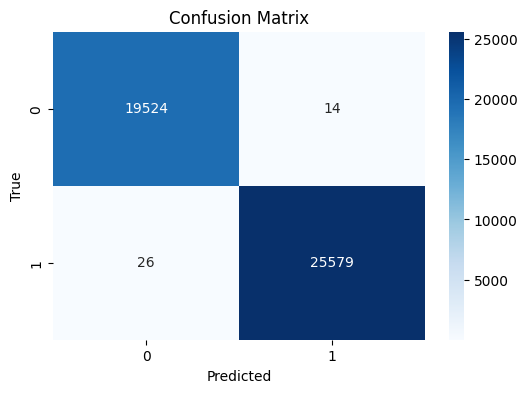

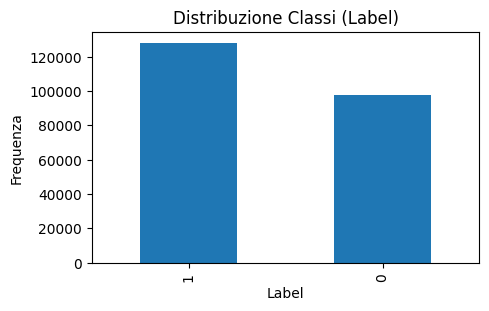

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


plt.figure(figsize=(5,3))
y.value_counts().plot(kind="bar")
plt.title("Distribuzione Classi (Label)")
plt.xlabel("Label")
plt.ylabel("Frequenza")
plt.show()

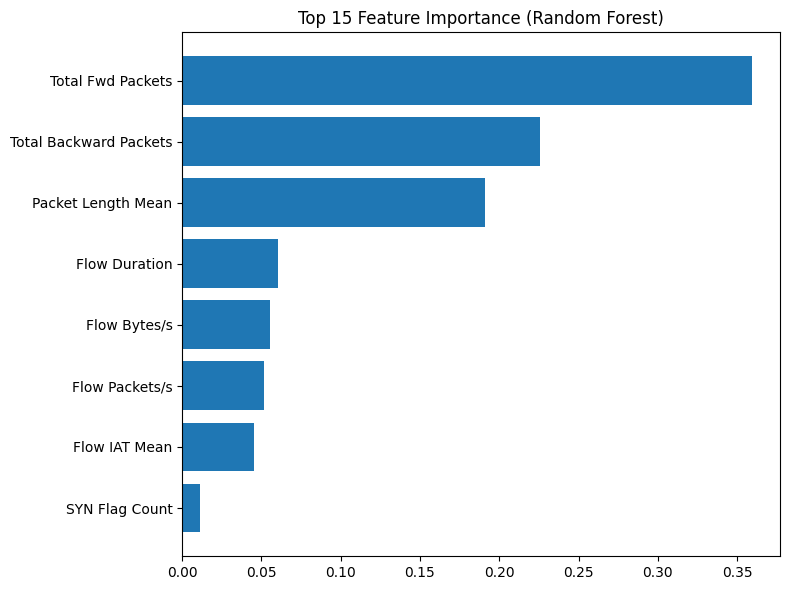

In [ ]:
importances = rf.feature_importances_
indices = importances.argsort()[-15:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 15 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

## 4) Download di un file da copiare sulla macchina

In [ ]:
import joblib
joblib.dump(rf, "rf.joblib")

['rf.joblib']